In [1]:
#Problem 1: The Photoelectric Effect 

Calculated Planck's Constant: 6.351e-34 J·s
Work Function: 1.987 +/- 0.084 V


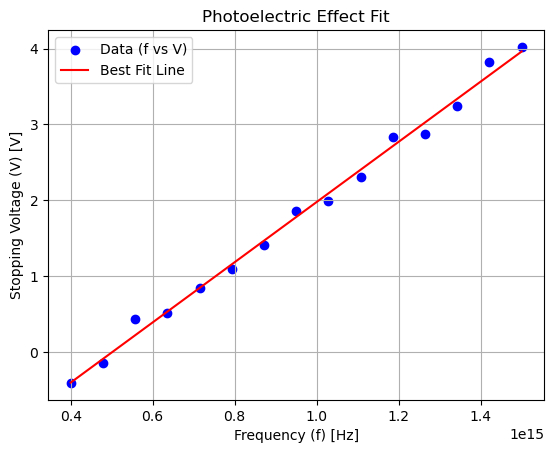

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load data 
data1 = np.loadtxt('photoelectric.csv', delimiter=',', skiprows=1)
f_data = data1[:, 0]
V_data = data1[:, 1]
e = 1.602e-19 

# Define linear model
def linear_model(f, m, c):
    return m * f + c

# Fit
popt1, pcov1 = curve_fit(linear_model, f_data, V_data)
m_fit, c_fit = popt1

# Uncertainty 
h_fit = m_fit * e  
phi_fit = -c_fit   
phi_err = np.sqrt(pcov1[1, 1]) 

print(f"Calculated Planck's Constant: {h_fit:.3e} J·s")
print(f"Work Function: {phi_fit:.3f} +/- {phi_err:.3f} V")

# Plot 
plt.scatter(f_data, V_data, label='Data (f vs V)', color='blue')
plt.plot(f_data, linear_model(f_data, *popt1), color='red', label='Best Fit Line')
plt.xlabel('Frequency (f) [Hz]')
plt.ylabel('Stopping Voltage (V) [V]')
plt.title('Photoelectric Effect Fit')
plt.legend()
plt.grid(True)
plt.show()

In [3]:
# Problem 2: Radioactive Decay (Non-Linear vs. Linearization) 

Calculated Half-Life: 7.28 minutes


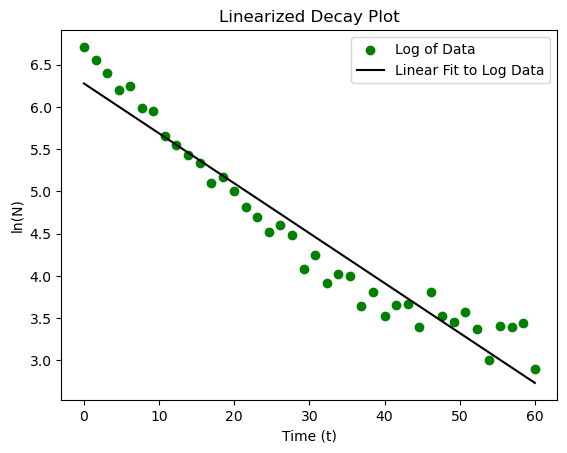

In [4]:
#Method A: The Non-Linear Fit 
def decay_model(t, N0, lam, bg):
    return N0 * np.exp(-lam * t) + bg 

data2 = np.loadtxt('decay_data.csv', delimiter=',', skiprows=1)
t_decay = data2[:, 0]
N_decay = data2[:, 1]

# Estimate initial guesses
p0 = [N_decay[0], 0.1, N_decay[-1]] 
popt2, pcov2 = curve_fit(decay_model, t_decay, N_decay, p0=p0) 

# Calculation of half-life 
half_life = np.log(2) / popt2[1]
print(f"Calculated Half-Life: {half_life:.2f} minutes")

#Method B: Linearization 
log_counts = np.log(N_decay) 
popt_lin, _ = curve_fit(linear_model, t_decay, log_counts) 

#Comparison Plot
plt.scatter(t_decay, log_counts, label='Log of Data', color='green')
plt.plot(t_decay, linear_model(t_decay, *popt_lin), color='black', label='Linear Fit to Log Data')
plt.xlabel('Time (t)')
plt.ylabel('ln(N)')
plt.title('Linearized Decay Plot')
plt.legend()
plt.show()

In [5]:
#Questions
#(i) Method A is definitely better. Method B ignores the background radiation entirely, while Method A includes it as a parameter. Because of this, Method A gives a much more accurate value for the decay constant and half-life.
#(ii) The log-plot doesn't stay straight the whole time. It fails at the end of the experiment where the counts are low. This happens because the constant background noise starts to dominate the signal, so the data stops following a pure exponential decay. I could make the fit better by subtracting the background from the data before taking the log.

In [6]:
#Problem 3: The Truth is in the Residuals 

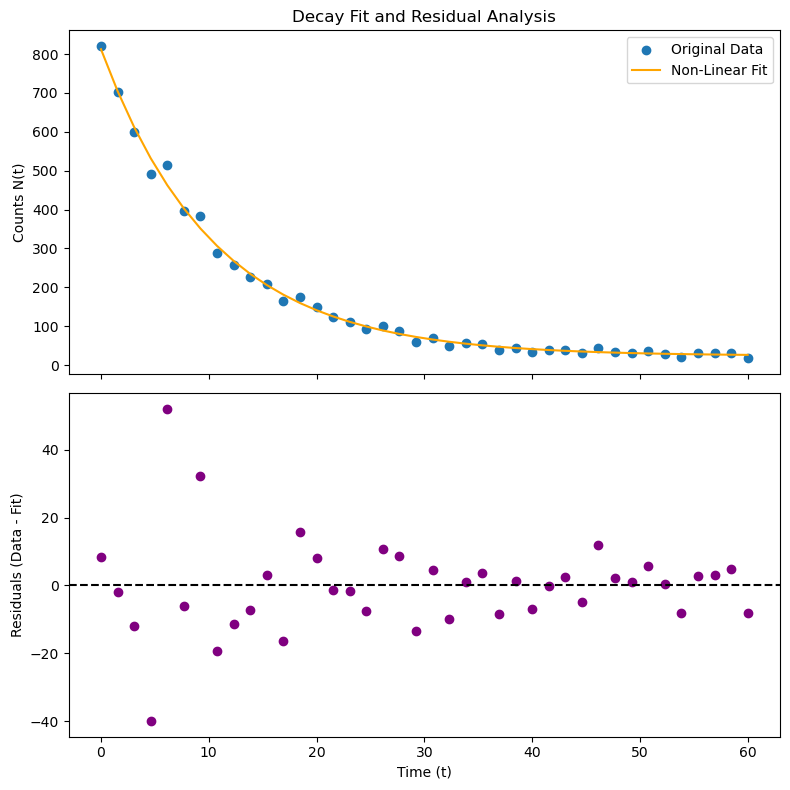

In [7]:
#Calculate residuals
residuals = N_decay - decay_model(t_decay, *popt2)

#Panel plot 
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 8))

# Top panel
ax1.scatter(t_decay, N_decay, label='Original Data')
ax1.plot(t_decay, decay_model(t_decay, *popt2), color='orange', label='Non-Linear Fit')
ax1.set_ylabel('Counts N(t)')
ax1.set_title('Decay Fit and Residual Analysis')
ax1.legend()

# Bottom panel 
ax2.scatter(t_decay, residuals, color='purple', marker='o')
ax2.axhline(0, color='black', linestyle='--')
ax2.set_ylabel('Residuals (Data - Fit)')
ax2.set_xlabel('Time (t)')

plt.tight_layout()
plt.show()

In [8]:
#Question
#If the residuals look like random noise, it means the model is a good fit. However, if they have a "U-shape" or a wave pattern, it tells me that my model is missing something like the background term or an extra decay constant and isn't fully capturing the physics of the data.

In [9]:
#Problem 4: Unknown Physics (Polynomial Approximation) 

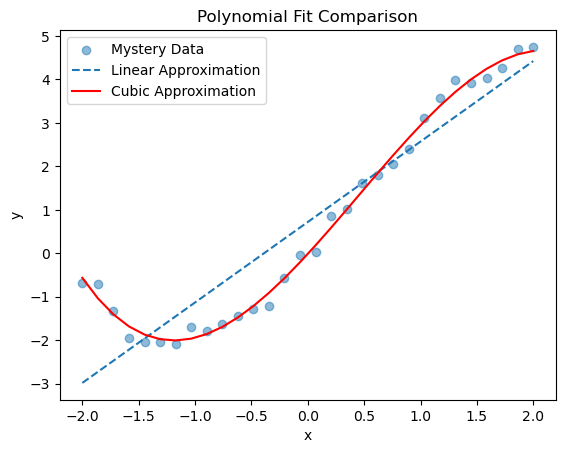

In [10]:
#Define models
def poly1(x, a, b):
    return a * x + b 

def poly3(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d 

#Load and fit
data3 = np.loadtxt('mystery_data.csv', delimiter=',', skiprows=1)
x_m, y_m = data3[:, 0], data3[:, 1]

popt_p1, _ = curve_fit(poly1, x_m, y_m) #the parameters optimized for polynomial 1
popt_p3, _ = curve_fit(poly3, x_m, y_m) #the parameters optimized for polynomial 3

# Plot 
plt.scatter(x_m, y_m, label='Mystery Data', alpha=0.5)
plt.plot(x_m, poly1(x_m, *popt_p1), label='Linear Approximation', linestyle='--')
plt.plot(x_m, poly3(x_m, *popt_p3), label='Cubic Approximation', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Polynomial Fit Comparison')
plt.show()

In [11]:
#Question
#Based on the plot, the linear fit doesn't really follow the curve, but the cubic fit (4 terms) matches the data points much better. I probably need at least 3 or 4 terms (up to x^2 or x^3) to actually capture the "mystery" physics here.